In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from FractionalLorenz import FractionalLorenz


def crossing_points(p1, curve1, p2, curve2, n_grid=2000):
    """
    Crossing points of two Lorenz curves defined on different grids.
    """
    # Common grid
    p = np.linspace(0, 1, n_grid)
    c1 = np.interp(p, p1, curve1)
    c2 = np.interp(p, p2, curve2)
    diff = c1 - c2
    idx = np.where(np.diff(np.sign(diff)) != 0)[0]
    crossings = []
    for k in idx:
        x1, x2 = p[k], p[k+1]
        y1, y2 = diff[k], diff[k+1]
        pcross = x1 - y1 * (x2-x1)/(y2-y1)
        # Ignore the trivial endpoints
        if 1e-8 < pcross < 1-1e-8:
            crossings.append(pcross)
    return crossings


def minimal_fractional_order(
    y1,
    y2,
    weight1=None,
    weight2=None,
    kind="relative",
    max_order=9,
    step=0.1,
):
    """
    Compute the minimal (possibly fractional) Lorenz order between curves of y1 and y2.
    y1, y2 : array-like
    """
    for s in range(1, max_order + 1):
        L1 = FractionalLorenz()
        L2 = FractionalLorenz()
        # Integer order
        L1.fit(
            y1,
            weight=weight1,
            dominance_param=s,
            kind=kind,
        )
        L2.fit(
            y2,
            weight=weight2,
            dominance_param=s,
            kind=kind,
        )
        p1 = np.concatenate(([0.0], L1.t1.squeeze()))
        c1 = np.concatenate(([0.0], L1.C))
        p2 = np.concatenate(([0.0], L2.t1.squeeze()))
        c2 = np.concatenate(([0.0], L2.C))
        cross = crossing_points(p1, c1, p2, c2)
        cross = [x for x in cross if 0.01 <= x <= 0.99]
        if len(cross) == 0:
            return float(s)
        # Fractional orders
        for c in np.arange(step, 1.0, step):
            L1.fit(
                y1,
                weight=weight1,
                dominance_param=s,
                fractional_param=c,
                kind=kind,
            )
            L2.fit(
                y2,
                weight=weight2,
                dominance_param=s,
                fractional_param=c,
                kind=kind,
            )
            c1 = np.concatenate(([0.0], L1.CC))
            c2 = np.concatenate(([0.0], L2.CC))
            cross = crossing_points(p1, c1, p2, c2)
            cross = [x for x in cross if 0.01 <= x <= 0.99]
            print(f"{s+c:.1f}: {cross}")
            if len(cross) == 0:
                return s + c

    return None

## Data

In [2]:
base = pd.read_csv('primo2012_2019poids.csv', sep=';', encoding='latin1')

# Sampling weights
weight_12 = base['poids_final']
weight_19 = base['poids_2019']

# Income
y = base['revtotmenagbase']

## Relative 

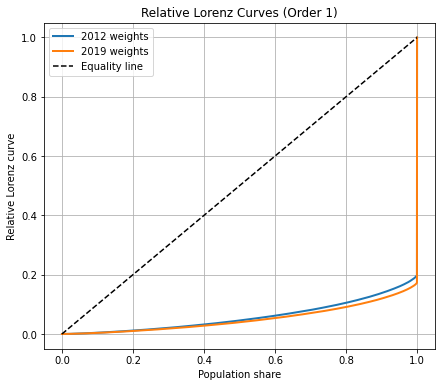

1.1: [0.014994686635867017]
1.2: [0.0157485124419465]
1.3: [0.016564098073566465]
1.4: [0.017465048309916843]
1.5: [0.018492381128200813]
1.6: [0.01973371434746345]
1.7: [0.02140370223110886]
1.8: [0.02411424185063453]
1.9: [0.029672870860542867]
2.1: [0.014994686635867017]
2.2: [0.0157485124419465]
2.3: [0.016564098073566465]
2.4: [0.017465048309916843]
2.5: [0.018492381128200813]
2.6: [0.01973371434746345]
2.7: [0.02140370223110886]
2.8: [0.02411424185063453]
2.9: [0.029672870860542867]
3.1: [0.017227696800254683]
3.2: [0.01726115261171384]
3.3: [0.017272599014867378]
3.4: [0.017278378349883543]
3.5: [0.01728186403267846]
3.6: [0.017284195382967077]
3.7: [0.01728586434563835]
3.8: [0.017287118101219398]
3.9: [0.01728809445105169]
4.1: [0.020280256699679193]
4.2: [0.02031083391607875]
4.3: [0.02032134879819489]
4.4: [0.02032666795327133]
4.5: [0.020329879357101135]
4.6: [0.02033202862695815]
4.7: [0.020333567913590953]
4.8: [0.02033472462198857]
4.9: [0.020335625615520683]
5.1: [0.011

In [3]:
# Order
order = 1
fractional_param = None
kind = "relative"

# Relative Lorenz curve (2012 weights)
L12 = FractionalLorenz()
L12.fit(y,weight=weight_12,dominance_param=order,fractional_param=fractional_param,kind=kind)

# Relative Lorenz curve (2019 weights)
L19 = FractionalLorenz()
L19.fit(y,weight=weight_19,dominance_param=order,fractional_param=fractional_param,kind=kind)

# Plot
p12 = np.concatenate(([0.0], L12.t1.squeeze()))
p19 = np.concatenate(([0.0], L19.t1.squeeze()))
if fractional_param is None:
    c12 = np.concatenate(([0.0], L12.C))
    c19 = np.concatenate(([0.0], L19.C))
else:
    c12 = np.concatenate(([0.0], L12.CC))
    c19 = np.concatenate(([0.0], L19.CC))

plt.figure(figsize=(7, 6))
plt.plot(p12, c12, lw=2, label="2012 weights")
plt.plot(p19, c19, lw=2, label="2019 weights")
plt.plot([0, 1], [0, 1], "k--", label="Equality line")
plt.xlabel("Population share")
plt.ylabel("Relative Lorenz curve")
plt.title(f"Relative Lorenz Curves (Order {order})")
#plt.xlim(0, 1)
#plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

#print("crossing_points", crossing_points(p12, c12, p19, c19))
#print("Inequality index", L12.inequality_index(), L19.inequality_index())
print(minimal_fractional_order(y,y,weight_12,weight_19,kind=kind))

## Absolute

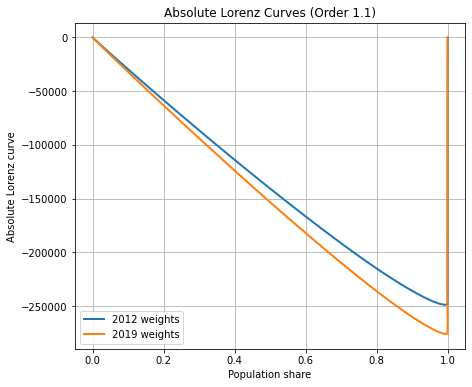

crossing_points []
Inequality index 272963.5708410438 298958.9493564784
1.0


In [4]:
# Order
order = 1
kind = "absolute"
fractional_param = None

# Absolute Lorenz curve (2012 weights)
L12 = FractionalLorenz()
L12.fit(y,weight=weight_12,dominance_param=order,fractional_param=fractional_param,kind=kind)

# Absolute Lorenz curve (2019 weights)
L19 = FractionalLorenz()
L19.fit(y,weight=weight_19,dominance_param=order,fractional_param=fractional_param,kind=kind)

# Plot
# Plot
p12 = np.concatenate(([0.0], L12.t1.squeeze()))
p19 = np.concatenate(([0.0], L19.t1.squeeze()))
if fractional_param is None:
    c12 = np.concatenate(([0.0], L12.C))
    c19 = np.concatenate(([0.0], L19.C))
else:
    c12 = np.concatenate(([0.0], L12.CC))
    c19 = np.concatenate(([0.0], L19.CC))
plt.figure(figsize=(7, 6))
plt.plot(p12, c12, lw=2, label="2012 weights")
plt.plot(p19, c19, lw=2, label="2019 weights")
#plt.plot([0, 1], [0, 1], "k--", label="Equality line")

plt.xlabel("Population share")
plt.ylabel("Absolute Lorenz curve")
plt.title(f"Absolute Lorenz Curves (Order {order}.1)")
#plt.xlim(0, 1)
#plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

print("crossing_points", crossing_points(p12, c12, p19, c19))
print("Inequality index", L12.inequality_index(), L19.inequality_index())
print(minimal_fractional_order(y,y,weight_12,weight_19,kind=kind))

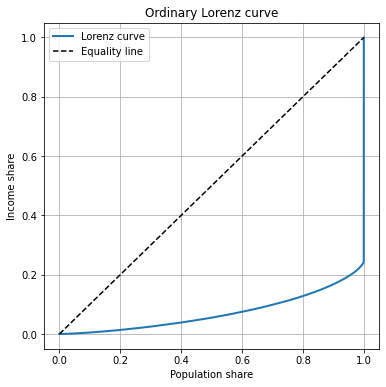

In [5]:
# Income
y = np.sort(y.to_numpy())

n = len(y)

# Population shares
p = np.arange(1, n + 1) / n

# Relative Lorenz curve
L = np.cumsum(y) / np.sum(y)

# Add the origin
p = np.concatenate(([0], p))
L = np.concatenate(([0], L))

plt.figure(figsize=(6, 6))
plt.plot(p, L, lw=2, label="Lorenz curve")
plt.plot([0, 1], [0, 1], "k--", label="Equality line")
plt.xlabel("Population share")
plt.ylabel("Income share")
plt.title("Ordinary Lorenz curve")
plt.grid(True)
plt.legend()
plt.show()